# 🏙️ Dự Đoán Giá BĐS TP.HCM — Ultimate v10
## v6 Features + v7 Anti-Leakage + v8 Architecture + v10 Optimizations
---
**Cải tiến so với v9:**
- 🔴 Cell 1: thêm `optuna` vào install
- 🟠 Cell 3: bổ sung z-score filter theo `project_type × ward` (phát hiện lỗi nhập đơn vị tỉ/triệu)
- 🟠 Cell 8: smoothing riêng cho từng cột + variance encoding song song với mean encoding
- 🟠 Cell 6: thêm `ward_quarter_median` trend feature (OOF-safe)
- 🟡 Cell 10: Optuna tuning LightGBM (100 trials)
- 🟡 Cell 11: Optuna tuning XGBoost (60 trials)
- 🟡 Cell 16: meta-learner chuyển từ RidgeCV → LightGBM nhỏ (học phân khúc)


## Cell 1 — Install & Import

In [ ]:
!pip install lightgbm xgboost catboost scikit-learn shap pandas numpy scipy matplotlib seaborn tensorflow optuna -q

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    USE_OPTUNA = True
    print("✅Optuna ready")
except ImportError:
    USE_OPTUNA = False
    print("⚠️  Optuna not installed — dùng params mặc định")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.feature_selection import RFE
import lightgbm as lgb
import xgboost as xgb
import shap

try:
    from catboost import CatBoostRegressor
    USE_CATBOOST = True
    print("✅ CatBoost ready")
except ImportError:
    USE_CATBOOST = False
    print("⚠️  CatBoost not installed — pip install catboost")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
    USE_ANN = True
    print(f"✅ TensorFlow {tf.__version__} ready")
except ImportError:
    USE_ANN = False
    print("⚠️  TensorFlow not installed — ANN will be skipped")

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print("\n✅ Import thành công!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.5 MB/s eta 0:00:00
✅ Optuna ready
✅ CatBoost ready
✅ TensorFlow 2.20.0 ready

✅ Import thành công!


## Cell 2 — Load & Audit Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/Shareddrives/KTV/KIẾN TẬP/Data/data_final_processed.csv'
# Option B: upload trực tiếp
# from google.colab import files; uploaded = files.upload(); DATA_PATH = list(uploaded.keys())[0]

df_raw = pd.read_csv(DATA_PATH)
print(f"✅ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")

price_m2 = df_raw['price_per_m2_vnd'] / 1e6
print(f"\nprice/m² (triệu VND):  min={price_m2.min():.2f}  max={price_m2.max():.0f}  "
      f"median={price_m2.median():.1f}  skew={price_m2.skew():.2f}")
print(f"  < 5 triệu : {(price_m2 < 5).sum()} rows  |  > 1200 triệu: {(price_m2 > 1200).sum()} rows")

miss = df_raw.isnull().sum().sort_values(ascending=False)
print("\nMissing values (top 15):")
print(miss[miss > 0].head(15).to_string())


Mounted at /content/drive
✅ Loaded: 5,659 rows × 51 cols

price/m² (triệu VND):  min=22.92  max=784  median=63.0  skew=2.88
  < 5 triệu : 0 rows  |  > 1200 triệu: 0 rows

Missing values (top 15):
Series([], )


## Cell 3 — Data Cleaning & Outlier Filter

In [ ]:
df = df_raw.copy()
n0 = len(df)

df = df[
    (df['price_per_m2_vnd'] >= 5e6)   &
    (df['price_per_m2_vnd'] <= 1200e6) &
    (df['area_m2'] >= 15)              &
    (df['area_m2'] <= 2000)
].copy()
print(f"Sau hard filter: {len(df):,} rows (loại {n0-len(df)})")

_proj_mean = df.groupby('project_name')['price_per_m2_vnd'].transform('mean')
_proj_std  = df.groupby('project_name')['price_per_m2_vnd'].transform('std').replace(0, 1e-6)
_z_proj    = (df['price_per_m2_vnd'] - _proj_mean) / _proj_std
mask_extreme     = (_z_proj.abs() > 7) & (df['price_per_m2_vnd'] > 500e6)
mask_small_crowd = (df['area_m2'] < 50) & (df['bedrooms'] >= 3)
df = df[~(mask_extreme | mask_small_crowd)].copy()
print(f"Sau outlier filter (project z-score): {len(df):,} rows")

# [v10] Z-score filter theo project_type × ward — phát hiện lỗi nhập đơn vị
# (vd: nhập 5 tỉ thay vì 5 triệu → z-score > 3 trong cùng phân khúc × phường)
if 'ward' in df.columns and 'project_type' in df.columns:
    _seg_mean = df.groupby(['project_type', 'ward'])['price_per_m2_vnd'].transform('mean')
    _seg_std  = df.groupby(['project_type', 'ward'])['price_per_m2_vnd'].transform('std').fillna(1e-6).replace(0, 1e-6)
    _z_seg    = (df['price_per_m2_vnd'] - _seg_mean) / _seg_std
    mask_seg_outlier = _z_seg.abs() > 3.5
    n_before = len(df)
    df = df[~mask_seg_outlier].copy()
    print(f"Sau ward×type z-score filter (>3.5σ): {len(df):,} rows (loại {n_before - len(df)})")
else:
    print("⚠️  ward/project_type chưa có → bỏ qua ward×type filter")

DROP_ALWAYS = [
    'note', 'source_listing_id', 'listing_url', 'source_url', 'project_id',
    'contact_name', 'contact_phone_masked', 'address', 'city', 'expired_at',
    'listing_description', 'project_description', 'title', 'street',
    'source_name', 'project_status', 'longitude', 'latitude', 'price_total_vnd',
]
df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], inplace=True)

for col in ['posted_at', 'snapshot_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

def normalize_ownership(x):
    if pd.isna(x): return 'Unknown'
    x = str(x).lower()
    if 'lâu dài' in x or 'vĩnh viễn' in x: return 'So_hong_lau_dai'
    if 'từng căn' in x:                      return 'So_hong_tung_can'
    if 'sổ hồng' in x:                       return 'So_hong_khac'
    return 'Khac'

df['ownership'] = df['ownership'].apply(normalize_ownership)
df['direction'] = df['direction'].fillna('Chua_ro')
if 'ward' in df.columns:
    df['ward'] = df['ward'].str.strip().str.lower().str.title()
print(f"\n✅ Shape sau cleaning: {df.shape}")


Sau hard filter: 5,659 rows (loại 0)
Sau outlier filter (project z-score): 5,659 rows
Sau ward×type z-score filter (>3.5σ): 5,609 rows (loại 50)

✅ Shape sau cleaning: (5609, 36)


## Cell 4 — Target Transform & Stratified Split
> Split xảy ra TRƯỚC mọi fit. Mọi thống kê chỉ compute trên train.

In [ ]:
TARGET_RAW = 'price_per_m2_vnd'
TARGET_COL = 'log_price_m2'

df[TARGET_COL] = np.log1p(df[TARGET_RAW] / 1e6)
print(f"Target: mean={df[TARGET_COL].mean():.4f}  std={df[TARGET_COL].std():.4f}  skew={df[TARGET_COL].skew():.4f}")

price_bucket = pd.cut(df[TARGET_RAW], bins=[0,50e6,100e6,200e6,np.inf], labels=[0,1,2,3])
df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=price_bucket)
print(f"Train+Val : {len(df_trainval):,}  |  Test: {len(df_test):,}")


Target: mean=4.2822  std=0.5525  skew=1.3069
Train+Val : 4,487  |  Test: 1,122


## Cell 5 — Imputation (fit on train only)

In [ ]:
def fit_imputer(df_train):
    imp = {}
    imp['types_no_towers'] = ['Biệt thự liền kề', 'Shophouse', 'Nhà mặt phố', 'Dự án khác']

    for col in ['num_towers','total_apartment','construction_density','launch_year','handover_year']:
        if col not in df_train.columns: continue
        imp[f'{col}_by_proj'] = df_train.groupby('project_name')[col].median().to_dict()
        imp[f'{col}_by_type'] = df_train.groupby('project_type')[col].median().to_dict()
        imp[f'{col}_global']  = df_train[col].median()

    for col in ['dist_cbd_km','dist_metro_km','dist_river_lake_km','dist_highway_km',
                'dist_airport_km','dist_market','dist_school','dist_park','dist_hospital']:
        if col not in df_train.columns: continue
        imp[f'{col}_by_ward'] = df_train.groupby('ward')[col].median().to_dict() if 'ward' in df_train else {}
        imp[f'{col}_global']  = df_train[col].median()

    if 'land_area_ha' in df_train.columns:
        imp['land_area_ha_by_proj'] = df_train.groupby('project_name')['land_area_ha'].median().to_dict()
        imp['land_area_ha_global']  = df_train['land_area_ha'].median()

    # [v6] proj_median_area: cần để tính area_ratio_in_proj
    imp['proj_median_area']   = df_train.groupby('project_name')['area_m2'].median().to_dict()
    imp['global_median_area'] = df_train['area_m2'].median()
    for col in ['ward', 'investor']:
        imp[f'{col}_fill'] = 'Unknown'
    return imp


def apply_imputer(df_in, imp):
    df_out = df_in.copy()
    if 'num_towers' in df_out.columns:
        df_out['is_null_towers'] = df_out['num_towers'].isnull().astype(int)

    for col in ['total_apartment','construction_density','launch_year','handover_year']:
        if col not in df_out.columns: continue
        mask = df_out[col].isna()
        if mask.sum() == 0: continue
        df_out.loc[mask, col] = df_out.loc[mask,'project_name'].map(imp.get(f'{col}_by_proj',{}))
        mask = df_out[col].isna()
        df_out.loc[mask, col] = df_out.loc[mask,'project_type'].map(imp.get(f'{col}_by_type',{}))
        df_out[col].fillna(imp.get(f'{col}_global', 0), inplace=True)

    if 'num_towers' in df_out.columns:
        df_out.loc[df_out['project_type'].isin(imp.get('types_no_towers',[])), 'num_towers'] = 0
        mask = df_out['num_towers'].isna()
        if mask.sum() > 0:
            df_out.loc[mask,'num_towers'] = df_out.loc[mask,'project_name'].map(imp.get('num_towers_by_proj',{}))
            mask = df_out['num_towers'].isna()
            df_out.loc[mask,'num_towers'] = df_out.loc[mask,'project_type'].map(imp.get('num_towers_by_type',{}))
            df_out['num_towers'].fillna(imp.get('num_towers_global', 0), inplace=True)

    for col in ['dist_cbd_km','dist_metro_km','dist_river_lake_km','dist_highway_km',
                'dist_airport_km','dist_market','dist_school','dist_park','dist_hospital']:
        if col not in df_out.columns: continue
        mask = df_out[col].isna()
        if mask.sum() == 0: continue
        if 'ward' in df_out.columns:
            df_out.loc[mask, col] = df_out.loc[mask,'ward'].map(imp.get(f'{col}_by_ward',{}))
        df_out[col].fillna(imp.get(f'{col}_global', 0), inplace=True)

    if 'land_area_ha' in df_out.columns:
        mask = df_out['land_area_ha'].isna()
        if mask.sum() > 0:
            df_out.loc[mask,'land_area_ha'] = df_out.loc[mask,'project_name'].map(imp.get('land_area_ha_by_proj',{}))
            df_out['land_area_ha'].fillna(imp.get('land_area_ha_global', 0), inplace=True)

    for col in ['ward','investor']:
        if col in df_out.columns:
            df_out[col].fillna(imp.get(f'{col}_fill','Unknown'), inplace=True)

    # [v6] proj_median_area
    df_out['proj_median_area'] = (
        df_out['project_name'].map(imp['proj_median_area']).fillna(imp['global_median_area'])
    )
    return df_out


print("Fitting imputer on train...")
imp_params      = fit_imputer(df_trainval)
df_trainval_imp = apply_imputer(df_trainval, imp_params)
df_test_imp     = apply_imputer(df_test,     imp_params)
print(f"✅ Imputation done — train: {df_trainval_imp.shape}, test: {df_test_imp.shape}")


Fitting imputer on train...
✅ Imputation done — train: (4487, 39), test: (1122, 39)


## Cell 6 — Feature Engineering (v6 + v7 Combined)

In [ ]:
def build_features(df_in):
    df_out = df_in.copy()

    # Date features
    if 'posted_at' in df_out.columns:
        df_out['posted_month']   = df_out['posted_at'].dt.month
        df_out['posted_year']    = df_out['posted_at'].dt.year.fillna(2024).astype(int)
        df_out['posted_quarter'] = df_out['posted_at'].dt.quarter
        if 'snapshot_date' in df_out.columns:
            df_out['listing_age_days'] = (df_out['snapshot_date'] - df_out['posted_at']).dt.days.clip(lower=0).fillna(0)

    # Project timing
    if 'launch_year' in df_out.columns and 'posted_year' in df_out.columns:
        df_out['project_age_years'] = df_out['posted_year'] - df_out['launch_year']
    if 'handover_year' in df_out.columns and 'posted_year' in df_out.columns:
        df_out['years_to_handover'] = (df_out['handover_year'] - df_out['posted_year']).clip(-5, 10)
    if 'handover_year' in df_out.columns and 'launch_year' in df_out.columns:
        df_out['build_duration'] = (df_out['handover_year'] - df_out['launch_year']).clip(0, 15)  # [v6]

    # Room / area
    df_out['room_total']      = df_out['bedrooms'] + df_out['bathrooms']
    df_out['bed_bath_ratio']  = df_out['bedrooms'] / (df_out['bathrooms'] + 0.5)
    df_out['area_per_room']   = df_out['area_m2']  / (df_out['room_total'] + 1)
    df_out['area_efficiency'] = df_out['area_m2']  / (df_out['bedrooms'] + 1)

    # [v6] area_ratio_in_proj
    if 'proj_median_area' in df_out.columns:
        df_out['area_ratio_in_proj'] = df_out['area_m2'] / (df_out['proj_median_area'] + 1e-6)
        df_out['log_area_ratio']     = np.log1p(df_out['area_ratio_in_proj'])

    # Amenity
    amenity_cols = [c for c in ['has_mall','has_school','has_hospital','has_park','has_pool','has_parkinglot'] if c in df_out.columns]
    df_out['amenity_score'] = df_out[amenity_cols].sum(axis=1)

    # Distance composites (dist_school dropped — spurious correlation)
    dist_clean = [c for c in ['dist_cbd_km','dist_metro_km','dist_river_lake_km',
                               'dist_highway_km','dist_airport_km','dist_market',
                               'dist_park','dist_hospital'] if c in df_out.columns]
    if dist_clean:
        df_out['dist_avg']    = df_out[dist_clean].mean(axis=1)
        df_out['dist_min']    = df_out[dist_clean].min(axis=1)
        df_out['accessibility'] = 1.0 / (df_out['dist_avg'] + 1.0)

    # Project scale
    if all(c in df_out.columns for c in ['total_apartment','num_towers']):
        df_out['apt_per_tower']      = df_out['total_apartment'] / (df_out['num_towers'] + 1)
        df_out['project_size_index'] = df_out['num_towers'] * df_out['apt_per_tower']

    # CBD & Metro proximity
    if 'dist_cbd_km' in df_out.columns:
        df_out['cbd_inv']         = 1.0 / (df_out['dist_cbd_km'] + 0.5)
        df_out['area_x_dist_cbd'] = df_out['area_m2'] * df_out['dist_cbd_km']
        df_out['cbd_x_amenity']   = df_out['cbd_inv'] * df_out['amenity_score']

    if 'dist_metro_km' in df_out.columns:
        df_out['metro_inv']    = 1.0 / (df_out['dist_metro_km'] + 0.5)
        df_out['metro_x_area'] = df_out['metro_inv'] * df_out['area_m2']

    df_out['area_x_bedrooms'] = df_out['area_m2'] * df_out['bedrooms']
    df_out['area_x_amenity']  = df_out['area_m2'] * df_out['amenity_score']

    # [v6] location_tier + tier interactions (không dùng giá → no leakage)
    if 'dist_cbd_km' in df_out.columns:
        df_out['location_tier'] = pd.cut(
            df_out['dist_cbd_km'], bins=[0,2,5,10,20,np.inf], labels=[5,4,3,2,1]
        ).astype(float)
        df_out['tier_x_amenity'] = df_out['location_tier'] * df_out['amenity_score']
        df_out['tier_x_area']    = df_out['location_tier'] * df_out['area_m2']

    # Density ratio
    if all(c in df_out.columns for c in ['construction_density','land_area_ha']):
        df_out['density_norm'] = df_out['construction_density'] / (df_out['land_area_ha'] + 1)

    # [v10] ward_quarter_median — trend signal, encode OOF-safe trong Cell 8
    # Ở đây chỉ tạo composite key; giá trị thực được gán sau khi split (tránh leakage)
    if all(c in df_out.columns for c in ['ward', 'posted_year', 'posted_quarter']):
        df_out['ward_quarter_key'] = (
            df_out['ward'].astype(str) + '_'
            + df_out['posted_year'].astype(str) + 'Q'
            + df_out['posted_quarter'].astype(str)
        )

    drop_post = [c for c in ['posted_at','snapshot_date','dist_school','proj_median_area'] if c in df_out.columns]
    df_out.drop(columns=drop_post, inplace=True)
    return df_out


df_trainval_fe = build_features(df_trainval_imp)
df_test_fe     = build_features(df_test_imp)
new_feats = [c for c in df_trainval_fe.columns if c not in df_trainval_imp.columns]
print(f"✅ FE done — Train: {df_trainval_fe.shape}  |  {len(new_feats)} new features")
print("  ", new_feats)


✅ FE done — Train: (4487, 66)  |  31 new features
   ['posted_month', 'posted_year', 'posted_quarter', 'listing_age_days', 'project_age_years', 'years_to_handover', 'build_duration', 'room_total', 'bed_bath_ratio', 'area_per_room', 'area_efficiency', 'area_ratio_in_proj', 'log_area_ratio', 'amenity_score', 'dist_avg', 'dist_min', 'accessibility', 'apt_per_tower', 'project_size_index', 'cbd_inv', 'area_x_dist_cbd', 'cbd_x_amenity', 'metro_inv', 'metro_x_area', 'area_x_bedrooms', 'area_x_amenity', 'location_tier', 'tier_x_amenity', 'tier_x_area', 'density_norm', 'ward_quarter_key']


## Cell 7 — Log Transform Skewed Features (fit on train)

In [ ]:
LOG_CANDIDATES = [
    'area_m2', 'bedrooms', 'bathrooms',
    'dist_river_lake_km', 'dist_market', 'dist_highway_km',
    'construction_density', 'apt_per_tower', 'land_area_ha',
    'total_apartment', 'project_size_index',
]

LOG_TRANSFORM_FEATS = []
print("Skewness check (train):")
for feat in LOG_CANDIDATES:
    if feat not in df_trainval_fe.columns: continue
    s = df_trainval_fe[feat].skew()
    if abs(s) > 1.0:
        LOG_TRANSFORM_FEATS.append(feat)
        s_after = np.log1p(df_trainval_fe[feat].clip(lower=0)).skew()
        improved = "✅" if abs(s_after) < abs(s) else "➖"
        print(f"  {improved} {feat:<35}: {s:>6.3f} → {s_after:>6.3f}")

# Apply transform
for feat in LOG_TRANSFORM_FEATS:
    df_trainval_fe[f'log_{feat}'] = np.log1p(df_trainval_fe[feat].clip(lower=0))
    df_test_fe[f'log_{feat}']     = np.log1p(df_test_fe[feat].clip(lower=0))

print(f"\n✅ Log-transformed {len(LOG_TRANSFORM_FEATS)} features")
print(f"   Train: {df_trainval_fe.shape}  |  Test: {df_test_fe.shape}")


Skewness check (train):
  ✅ area_m2                            :  1.377 →  0.248
  ✅ bedrooms                           :  3.495 →  0.347
  ✅ bathrooms                          :  4.685 →  0.720
  ✅ dist_river_lake_km                 :  4.559 →  0.896
  ✅ dist_market                        :  2.476 →  0.835
  ✅ dist_highway_km                    :  1.314 → -0.139
  ✅ construction_density               :  1.157 →  0.671
  ✅ apt_per_tower                      :  3.825 → -0.259

✅ Log-transformed 8 features
   Train: (4487, 74)  |  Test: (1122, 74)


## Cell 8 — Target Encoding OOF + Variance Encoding + Ward×Quarter Trend
> **BUG FIX (v9):** `ward_te_x_area` luôn dùng `log_area_m2` nếu có, fallback về `area_m2` với cảnh báo rõ ràng  
> **[v10]:** Smoothing riêng từng cột (adaptive theo global_std/per_cat_std). Thêm variance encoding song song. Thêm `ward_quarter_median_te` trend feature (OOF-safe).


In [ ]:
TARGET_ENC_COLS = [c for c in ['project_name','ward','investor'] if c in df_trainval_fe.columns]

# [v10] Smoothing riêng từng cột: project_name (nhiều categories, ít sample) cần smoothing cao hơn
# Công thức: smoothing ≈ global_std / per_category_std_median
def compute_adaptive_smoothing(df_train, col, target_col, default=10):
    """Smoothing cao hơn khi category có ít samples / variance thấp."""
    g = df_train.groupby(col)[target_col]
    per_cat_std  = g.std().median()
    global_std   = df_train[target_col].std()
    if per_cat_std and per_cat_std > 0:
        s = int(round(global_std / per_cat_std * 10))
        return max(5, min(s, 100))
    return default

SMOOTHING_MAP = {}
for col in TARGET_ENC_COLS:
    s = compute_adaptive_smoothing(df_trainval_fe, col, TARGET_COL)
    SMOOTHING_MAP[col] = s
print("Adaptive smoothing:", SMOOTHING_MAP)


def target_encode_oof(df_train_in, df_test_in, cat_cols, target_col,
                      smoothing_map=None, n_folds=5, random_state=42):
    """
    Mean target encoding + variance encoding (song song).
    smoothing_map: dict col → smoothing value (nếu None dùng 10 cho tất cả).
    """
    df_tr = df_train_in.copy()
    df_te = df_test_in.copy()
    global_mean = df_tr[target_col].mean()
    global_var  = df_tr[target_col].var()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    for col in cat_cols:
        smoothing = (smoothing_map or {}).get(col, 10)
        col_mean_out = f'{col}_te'
        col_var_out  = f'{col}_var_te'

        # ── Mean encoding OOF ──
        df_tr[col_mean_out] = np.nan
        for idx_enc, idx_fill in kf.split(df_tr):
            enc_df     = df_tr.iloc[idx_enc][[col, target_col]]
            stats_fold = enc_df.groupby(col)[target_col].agg(['mean','count'])
            stats_fold['smooth'] = (
                (stats_fold['count'] * stats_fold['mean'] + smoothing * global_mean)
                / (stats_fold['count'] + smoothing)
            )
            fill_cats = df_tr.iloc[idx_fill][col]
            df_tr.loc[df_tr.index[idx_fill], col_mean_out] = (
                fill_cats.map(stats_fold['smooth']).fillna(global_mean).values
            )
        full_stats = df_tr.groupby(col)[target_col].agg(['mean','count'])
        full_stats['smooth'] = (
            (full_stats['count'] * full_stats['mean'] + smoothing * global_mean)
            / (full_stats['count'] + smoothing)
        )
        df_te[col_mean_out] = df_te[col].map(full_stats['smooth']).fillna(global_mean)

        # ── [v10] Variance encoding: độ biến động giá trong category ──
        # Variance cao = project có nhiều loại căn → feature informative
        var_stats = df_tr.groupby(col)[target_col].var().rename('var')
        # Smoothed variance: kéo về global_var khi count nhỏ
        count_stats = df_tr.groupby(col)[target_col].count().rename('cnt')
        smooth_var = (count_stats * var_stats + smoothing * global_var) / (count_stats + smoothing)
        df_tr[col_var_out] = df_tr[col].map(smooth_var).fillna(global_var)
        df_te[col_var_out] = df_te[col].map(smooth_var).fillna(global_var)

        print(f"  {col} → {col_mean_out} (smooth={smoothing}) + {col_var_out}  "
              f"(null filled: {df_tr[col_mean_out].isnull().sum()})")
    return df_tr, df_te


print(f"Target Encoding OOF (5-fold, adaptive smoothing)...")
df_tr_te, df_te_te = target_encode_oof(
    df_trainval_fe, df_test_fe,
    cat_cols=TARGET_ENC_COLS, target_col=TARGET_COL,
    smoothing_map=SMOOTHING_MAP,
)
print("✅ Target Encoding + Variance Encoding done")

# [v10] ward_quarter_median — OOF-safe trend signal
# Encode median price/m² trong cùng ward × quý, fit chỉ trên train
if 'ward_quarter_key' in df_tr_te.columns:
    global_median = df_tr_te[TARGET_COL].median()
    wq_stats = df_tr_te.groupby('ward_quarter_key')[TARGET_COL].agg(['median','count'])
    wq_smooth = 10
    wq_stats['smooth_median'] = (
        (wq_stats['count'] * wq_stats['median'] + wq_smooth * global_median)
        / (wq_stats['count'] + wq_smooth)
    )
    df_tr_te['ward_quarter_median_te'] = df_tr_te['ward_quarter_key'].map(wq_stats['smooth_median']).fillna(global_median)
    df_te_te['ward_quarter_median_te'] = df_te_te['ward_quarter_key'].map(wq_stats['smooth_median']).fillna(global_median)
    # Drop key column
    df_tr_te.drop(columns=['ward_quarter_key'], inplace=True, errors='ignore')
    df_te_te.drop(columns=['ward_quarter_key'], inplace=True, errors='ignore')
    print("✅ ward_quarter_median_te added (OOF-safe via train stats)")
else:
    print("⚠️  ward_quarter_key không có → ward_quarter_median_te bỏ qua")

# ── ward_te interactions ──────────────────────────────────────────────────────
if 'log_area_m2' in df_tr_te.columns:
    area_col_for_te = 'log_area_m2'
    print("  ward_te_x_area: dùng log_area_m2 ✅")
else:
    area_col_for_te = 'area_m2'
    print("  ward_te_x_area: dùng area_m2 (log_area_m2 chưa được tạo ở Cell 7) ⚠️")

for _df in [df_tr_te, df_te_te]:
    _df['ward_te_x_area']     = _df['ward_te'] * _df[area_col_for_te]
    _df['ward_te_x_dist_cbd'] = _df['ward_te'] * _df['dist_cbd_km']
    _df['ward_te_x_amenity']  = _df['ward_te'] * _df['amenity_score']
    if 'log_area_ratio' in _df.columns:
        _df['ward_te_x_log_area_ratio'] = _df['ward_te']         * _df['log_area_ratio']
        _df['proj_te_x_log_area_ratio'] = _df['project_name_te'] * _df['log_area_ratio']

print(f"✅ ward_te & proj_te interaction features added")
print(f"   Train: {df_tr_te.shape}  |  Test: {df_te_te.shape}")


Adaptive smoothing: {'project_name': 29, 'ward': 22, 'investor': 27}
Target Encoding OOF (5-fold, adaptive smoothing)...
  project_name → project_name_te (smooth=29) + project_name_var_te  (null filled: 0)
  ward → ward_te (smooth=22) + ward_var_te  (null filled: 0)
  investor → investor_te (smooth=27) + investor_var_te  (null filled: 0)
✅ Target Encoding + Variance Encoding done
✅ ward_quarter_median_te added (OOF-safe via train stats)
  ward_te_x_area: dùng log_area_m2 ✅
✅ ward_te & proj_te interaction features added
   Train: (4487, 85)  |  Test: (1122, 85)


## Cell 9 — One-Hot Encoding + Feature Matrix

In [ ]:
OHE_COLS = [c for c in [
    'project_type','legal_status','furniture_status','direction','ownership','listing_type'
] if c in df_tr_te.columns]

DROP_BEFORE_TRAIN = list(set([
    TARGET_COL, TARGET_RAW, 'price_total_vnd', 'log_price_m2',
    'project_name', 'ward', 'investor',
    'dist_school',
] + LOG_TRANSFORM_FEATS))  # giữ log_ version, drop raw


def prepare_matrix(df_in, ohe_cols, drop_cols, ohe_vocab=None, fit=True):
    df_out = df_in.copy()
    df_out.drop(columns=[c for c in drop_cols if c in df_out.columns], inplace=True)
    if fit: ohe_vocab = {}
    for col in ohe_cols:
        if col not in df_out.columns: continue
        df_out[col] = df_out[col].fillna('Unknown').astype(str)
        if fit:
            vocab = sorted(df_out[col].unique()); ohe_vocab[col] = vocab
        else:
            vocab = ohe_vocab.get(col, [])
        for cat in vocab[1:]:
            df_out[f'{col}__{cat}'] = (df_out[col] == cat).astype(np.int8)
        df_out.drop(columns=[col], inplace=True)
    str_cols = df_out.select_dtypes(include='object').columns.tolist()
    if str_cols:
        print(f"  Drop string cols còn lại: {str_cols}")
        df_out.drop(columns=str_cols, inplace=True)
    null_sum = df_out.isnull().sum().sum()
    if null_sum > 0:
        print(f"  Còn {null_sum} NaN → fill 0")
        df_out.fillna(0, inplace=True)
    return df_out, ohe_vocab


y_trainval = df_tr_te[TARGET_COL].copy()
y_test     = df_te_te[TARGET_COL].copy()

X_trainval, ohe_vocab_ = prepare_matrix(df_tr_te, OHE_COLS, DROP_BEFORE_TRAIN, fit=True)
X_test, _              = prepare_matrix(df_te_te, OHE_COLS, DROP_BEFORE_TRAIN, ohe_vocab=ohe_vocab_, fit=False)
X_test = X_test.reindex(columns=X_trainval.columns, fill_value=0)

print(f"\n✅ Feature matrix:")
print(f"   X_trainval : {X_trainval.shape}")
print(f"   X_test     : {X_test.shape}")
print(f"   Null — train: {X_trainval.isnull().sum().sum()}  test: {X_test.isnull().sum().sum()}")



✅ Feature matrix:
   X_trainval : (4487, 88)
   X_test     : (1122, 88)
   Null — train: 0  test: 0


## Cell 10 — LightGBM Optuna Tuning + 5-Fold CV
> **[v10]:** Thay params cứng bằng Optuna (100 trials, TPE sampler). Nếu Optuna chưa cài → fallback về params mặc định hợp lý.


In [ ]:
# ── [v10] Optuna Hyperparameter Tuning cho LightGBM ────────────────────────
# Optuna tìm params tối ưu qua 100 trials thay vì dùng params cố định.
# Nếu Optuna chưa cài → fallback về params mặc định hợp lý.

LGB_BASE_PARAMS = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.03, 'n_estimators': 3000,
    'random_state': 42, 'verbose': -1, 'n_jobs': -1,
}

if USE_OPTUNA:
    import optuna
    from sklearn.model_selection import cross_val_score

    def lgb_objective(trial):
        params = {
            **LGB_BASE_PARAMS,
            'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 0.9),
            'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 0.9),
            'bagging_freq':      5,
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 3.0),
            'max_depth':        -1,
            'n_estimators':      500,   # ít hơn để trial nhanh
        }
        m = lgb.LGBMRegressor(**params)
        kf_opt = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        for tr_i, val_i in kf_opt.split(X_trainval):
            m.fit(X_trainval.iloc[tr_i], y_trainval.iloc[tr_i],
                  eval_set=[(X_trainval.iloc[val_i], y_trainval.iloc[val_i])],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
            pred = m.predict(X_trainval.iloc[val_i])
            scores.append(r2_score(np.expm1(y_trainval.iloc[val_i]), np.expm1(pred)))
        return np.mean(scores)

    print("Optuna LightGBM tuning (100 trials)...")
    lgb_study = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    lgb_study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)
    best_lgb = lgb_study.best_params
    print(f"✅ Best LGB params: {best_lgb}  R²={lgb_study.best_value:.4f}")
    lgb_params = {**LGB_BASE_PARAMS, **best_lgb, 'n_estimators': 3000,
                  'bagging_freq': 5, 'max_depth': -1}
else:
    print("⚠️  Optuna không có — dùng params mặc định")
    lgb_params = {
        **LGB_BASE_PARAMS,
        'num_leaves': 127, 'max_depth': -1,
        'min_child_samples': 15, 'feature_fraction': 0.75,
        'bagging_fraction': 0.80, 'bagging_freq': 5,
        'reg_alpha': 0.30, 'reg_lambda': 0.50,
    }

# ── 5-Fold CV với params đã tối ưu ──────────────────────────────────────────
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
y_tv_real = np.expm1(y_trainval)

lgb_oof_preds  = np.zeros(len(X_trainval))
lgb_best_iters = []

print(f"\nLightGBM {N_FOLDS}-Fold CV\n{'='*60}")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
    X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]
    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_tr_f, y_tr_f, eval_set=[(X_val_f, y_val_f)],
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    lgb_best_iters.append(m.best_iteration_)
    lgb_oof_preds[val_idx] = m.predict(X_val_f)
    r2_ = r2_score(np.expm1(y_val_f), np.expm1(lgb_oof_preds[val_idx]))
    mae_ = mean_absolute_error(np.expm1(y_val_f), np.expm1(lgb_oof_preds[val_idx]))
    mdape = np.median(np.abs((np.expm1(y_val_f) - np.expm1(lgb_oof_preds[val_idx])) / (np.expm1(y_val_f)+1e-6))) * 100
    print(f"  Fold {fold+1}: iter={m.best_iteration_:4d}  MAE={mae_:.2f}  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

lgb_oof_r2  = r2_score(y_tv_real, np.expm1(lgb_oof_preds))
lgb_oof_mae = mean_absolute_error(y_tv_real, np.expm1(lgb_oof_preds))
print(f"\nLightGBM OOF: MAE={lgb_oof_mae:.3f}  R²={lgb_oof_r2:.4f}")
print(f"Best iters: {lgb_best_iters}  → median={int(np.median(lgb_best_iters))}")

lgb_best_n = int(np.median(lgb_best_iters))
lgb_model  = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': lgb_best_n})
lgb_model.fit(X_trainval, y_trainval)
print(f"✅ LightGBM retrain xong — n_estimators={lgb_best_n}")


Optuna LightGBM tuning (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

✅ Best LGB params: {'num_leaves': 223, 'min_child_samples': 12, 'feature_fraction': 0.6164680816657073, 'bagging_fraction': 0.8692110912541993, 'reg_alpha': 1.4803421797588316, 'reg_lambda': 0.39366937819056413}  R²=0.9058

LightGBM 5-Fold CV
  Fold 1: iter= 819  MAE=10.82  R²=0.9027  MdAPE=6.48%
  Fold 2: iter=1144  MAE=9.22  R²=0.9144  MdAPE=5.84%
  Fold 3: iter=2992  MAE=10.89  R²=0.8971  MdAPE=6.67%
  Fold 4: iter=1651  MAE=10.02  R²=0.8908  MdAPE=6.40%
  Fold 5: iter= 804  MAE=9.24  R²=0.9284  MdAPE=5.99%

LightGBM OOF: MAE=10.038  R²=0.9072
Best iters: [819, 1144, 2992, 1651, 804]  → median=1144
✅ LightGBM retrain xong — n_estimators=1144


## Cell 11 — XGBoost Optuna Tuning + 5-Fold CV
> **[v10]:** Thay params cứng bằng Optuna (60 trials, TPE sampler). Nếu Optuna chưa cài → fallback về params mặc định hợp lý.


In [ ]:
# ── [v10] Optuna Hyperparameter Tuning cho XGBoost ─────────────────────────
XGB_BASE_PARAMS = {
    'objective': 'reg:absoluteerror', 'learning_rate': 0.03,
    'random_state': 42, 'tree_method': 'hist', 'verbosity': 0, 'n_jobs': -1,
}

if USE_OPTUNA:
    def xgb_objective(trial):
        params = {
            **XGB_BASE_PARAMS,
            'max_depth':          trial.suggest_int('max_depth', 4, 10),
            'min_child_weight':   trial.suggest_int('min_child_weight', 5, 30),
            'subsample':          trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'reg_alpha':          trial.suggest_float('reg_alpha', 0.0, 2.0),
            'reg_lambda':         trial.suggest_float('reg_lambda', 0.0, 3.0),
            'n_estimators':       500,
            'early_stopping_rounds': 50,
        }
        kf_opt = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        for tr_i, val_i in kf_opt.split(X_trainval):
            m = xgb.XGBRegressor(**params)
            m.fit(X_trainval.iloc[tr_i], y_trainval.iloc[tr_i],
                  eval_set=[(X_trainval.iloc[val_i], y_trainval.iloc[val_i])],
                  verbose=False)
            pred = m.predict(X_trainval.iloc[val_i])
            scores.append(r2_score(np.expm1(y_trainval.iloc[val_i]), np.expm1(pred)))
        return np.mean(scores)

    print("Optuna XGBoost tuning (60 trials)...")
    xgb_study = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    xgb_study.optimize(xgb_objective, n_trials=60, show_progress_bar=True)
    best_xgb = xgb_study.best_params
    print(f"✅ Best XGB params: {best_xgb}  R²={xgb_study.best_value:.4f}")
    xgb_params = {**XGB_BASE_PARAMS, **best_xgb, 'n_estimators': 3000,
                  'early_stopping_rounds': 150}
else:
    print("⚠️  Optuna không có — dùng params mặc định")
    xgb_params = {
        **XGB_BASE_PARAMS,
        'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 3000,
        'subsample': 0.80, 'colsample_bytree': 0.75,
        'reg_alpha': 0.30, 'reg_lambda': 1.0,
        'early_stopping_rounds': 150,
    }

xgb_oof_preds  = np.zeros(len(X_trainval))
xgb_best_iters = []

print(f"\nXGBoost {N_FOLDS}-Fold CV\n{'='*60}")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
    X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(X_tr_f, y_tr_f, eval_set=[(X_val_f, y_val_f)], verbose=False)
    xgb_best_iters.append(m.best_iteration)
    xgb_oof_preds[val_idx] = m.predict(X_val_f)
    r2_ = r2_score(np.expm1(y_val_f), np.expm1(xgb_oof_preds[val_idx]))
    mae_ = mean_absolute_error(np.expm1(y_val_f), np.expm1(xgb_oof_preds[val_idx]))
    mdape = np.median(np.abs((np.expm1(y_val_f) - np.expm1(xgb_oof_preds[val_idx])) / (np.expm1(y_val_f)+1e-6))) * 100
    print(f"  Fold {fold+1}: iter={m.best_iteration:4d}  MAE={mae_:.2f}  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

xgb_oof_r2  = r2_score(y_tv_real, np.expm1(xgb_oof_preds))
xgb_oof_mae = mean_absolute_error(y_tv_real, np.expm1(xgb_oof_preds))
print(f"\nXGBoost OOF: MAE={xgb_oof_mae:.3f}  R²={xgb_oof_r2:.4f}")

xgb_best_n = int(np.median(xgb_best_iters))
xgb_retrain_params = {k: v for k, v in xgb_params.items()
                      if k not in ('early_stopping_rounds', 'eval_metric')}
xgb_retrain_params['n_estimators'] = xgb_best_n
xgb_model = xgb.XGBRegressor(**xgb_retrain_params)
xgb_model.fit(X_trainval, y_trainval)
print(f"✅ XGBoost retrain xong — n_estimators={xgb_best_n}")


Optuna XGBoost tuning (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

✅ Best XGB params: {'max_depth': 9, 'min_child_weight': 6, 'subsample': 0.8836814514137444, 'colsample_bytree': 0.5591654284432664, 'reg_alpha': 1.3889560106859902, 'reg_lambda': 0.3800293693074486}  R²=0.9069

XGBoost 5-Fold CV
  Fold 1: iter= 927  MAE=10.89  R²=0.9018  MdAPE=6.51%
  Fold 2: iter=1196  MAE=9.25  R²=0.9112  MdAPE=5.71%
  Fold 3: iter=2968  MAE=10.88  R²=0.8950  MdAPE=6.59%
  Fold 4: iter=1739  MAE=9.75  R²=0.9015  MdAPE=6.33%
  Fold 5: iter=1045  MAE=8.92  R²=0.9379  MdAPE=6.06%

XGBoost OOF: MAE=9.939  R²=0.9097
✅ XGBoost retrain xong — n_estimators=1196


## Cell 12 — CatBoost 5-Fold CV

In [ ]:
if USE_CATBOOST:
    cat_params = {
        'iterations': 2000, 'learning_rate': 0.03, 'depth': 7,
        'l2_leaf_reg': 5, 'loss_function': 'MAE', 'eval_metric': 'MAE',
        'random_seed': 42, 'verbose': False, 'early_stopping_rounds': 150, 'task_type': 'CPU',
    }
    cat_oof_preds  = np.zeros(len(X_trainval))
    cat_best_iters = []

    print(f"CatBoost {N_FOLDS}-Fold CV\n{'='*60}")
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
        X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
        y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]
        m = CatBoostRegressor(**cat_params)
        m.fit(X_tr_f, y_tr_f, eval_set=(X_val_f, y_val_f))
        cat_best_iters.append(m.get_best_iteration())
        cat_oof_preds[val_idx] = m.predict(X_val_f)
        r2_ = r2_score(np.expm1(y_val_f), np.expm1(cat_oof_preds[val_idx]))
        mae_ = mean_absolute_error(np.expm1(y_val_f), np.expm1(cat_oof_preds[val_idx]))
        mdape = np.median(np.abs((np.expm1(y_val_f) - np.expm1(cat_oof_preds[val_idx])) / (np.expm1(y_val_f)+1e-6))) * 100
        print(f"  Fold {fold+1}: iter={m.get_best_iteration():4d}  MAE={mae_:.2f}  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

    cat_oof_r2  = r2_score(y_tv_real, np.expm1(cat_oof_preds))
    cat_oof_mae = mean_absolute_error(y_tv_real, np.expm1(cat_oof_preds))
    print(f"\nCatBoost OOF: MAE={cat_oof_mae:.3f}  R²={cat_oof_r2:.4f}")

    cat_best_n = int(np.median(cat_best_iters))
    cat_model  = CatBoostRegressor(**{**cat_params, 'iterations': cat_best_n, 'early_stopping_rounds': None})
    cat_model.fit(X_trainval, y_trainval)
    print(f"✅ CatBoost retrain xong — iterations={cat_best_n}")
else:
    cat_oof_preds = np.zeros(len(X_trainval))
    cat_oof_r2    = 0.0
    print("⚠️  CatBoost skipped")


CatBoost 5-Fold CV
  Fold 1: iter=1378  MAE=10.91  R²=0.9060  MdAPE=6.94%
  Fold 2: iter=1944  MAE=9.09  R²=0.9226  MdAPE=5.88%
  Fold 3: iter=1985  MAE=10.58  R²=0.9072  MdAPE=6.71%
  Fold 4: iter=1983  MAE=10.34  R²=0.8937  MdAPE=6.65%
  Fold 5: iter=1926  MAE=9.13  R²=0.9355  MdAPE=5.95%

CatBoost OOF: MAE=10.013  R²=0.9137
✅ CatBoost retrain xong — iterations=1944


## Cell 13 — Random Forest 5-Fold CV

In [ ]:
rf_oof_preds = np.zeros(len(X_trainval))
print(f"Random Forest {N_FOLDS}-Fold CV\n{'='*60}")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
    X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]
    rf_f = RandomForestRegressor(n_estimators=300, max_features=0.4,
                                  min_samples_leaf=3, n_jobs=-1, random_state=fold)
    rf_f.fit(X_tr_f, y_tr_f)
    rf_oof_preds[val_idx] = rf_f.predict(X_val_f)
    r2_ = r2_score(np.expm1(y_val_f), np.expm1(rf_oof_preds[val_idx]))
    mae_ = mean_absolute_error(np.expm1(y_val_f), np.expm1(rf_oof_preds[val_idx]))
    mdape = np.median(np.abs((np.expm1(y_val_f) - np.expm1(rf_oof_preds[val_idx])) / (np.expm1(y_val_f)+1e-6))) * 100
    print(f"  Fold {fold+1}: MAE={mae_:.2f}  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

rf_oof_r2  = r2_score(y_tv_real, np.expm1(rf_oof_preds))
rf_oof_mae = mean_absolute_error(y_tv_real, np.expm1(rf_oof_preds))
print(f"\nRandom Forest OOF: MAE={rf_oof_mae:.3f}  R²={rf_oof_r2:.4f}")
rf_model = RandomForestRegressor(n_estimators=400, max_features=0.4,
                                   min_samples_leaf=3, n_jobs=-1, random_state=42)
rf_model.fit(X_trainval, y_trainval)
print("✅ Random Forest retrain xong")


Random Forest 5-Fold CV
  Fold 1: MAE=10.67  R²=0.9125  MdAPE=6.93%
  Fold 2: MAE=9.32  R²=0.9153  MdAPE=6.27%
  Fold 3: MAE=11.06  R²=0.8920  MdAPE=6.88%
  Fold 4: MAE=9.84  R²=0.9068  MdAPE=6.49%
  Fold 5: MAE=9.07  R²=0.9400  MdAPE=6.15%

Random Forest OOF: MAE=9.993  R²=0.9135
✅ Random Forest retrain xong


## Cell 14 — ANN (Keras) 5-Fold CV
> **BUG FIX:** Trong fold loop, scale trực tiếp từ raw X (không pre-scale toàn bộ trước)  
> Trước: `X_tr_scaled = scaler.fit_transform(X_trainval)` rồi scale tiếp trong fold → double-scaling

In [ ]:
ann_oof_preds = np.zeros(len(X_trainval))

if USE_ANN:
    def build_ann(n_features):
        inp = keras.Input(shape=(n_features,))
        x   = layers.Dense(512, activation='relu')(inp)
        x   = layers.BatchNormalization()(x)
        x   = layers.Dropout(0.3)(x)
        x   = layers.Dense(256, activation='relu')(x)
        x   = layers.BatchNormalization()(x)
        x   = layers.Dropout(0.25)(x)
        x   = layers.Dense(128, activation='relu')(x)
        x   = layers.Dropout(0.2)(x)
        x   = layers.Dense(64, activation='relu')(x)
        out = layers.Dense(1)(x)
        model = keras.Model(inp, out)
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mae')
        return model

    # ── BUG FIX: KHÔNG pre-scale toàn bộ X_trainval ──────────────
    # Mỗi fold tự fit StandardScaler của riêng nó trên raw X_trainval.iloc[tr_idx]
    X_tv_arr = X_trainval.values  # raw, chưa scale

    print(f"ANN {N_FOLDS}-Fold CV\n{'='*60}")
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tv_arr)):
        Xf_tr_raw = X_tv_arr[tr_idx]
        Xf_val_raw = X_tv_arr[val_idx]
        yf_tr = y_trainval.values[tr_idx]
        yf_val = y_trainval.values[val_idx]

        # Scale chỉ fit trên fold train → không leakage, không double-scale
        sc_f = StandardScaler()
        Xf_tr_scaled  = sc_f.fit_transform(Xf_tr_raw)
        Xf_val_scaled = sc_f.transform(Xf_val_raw)

        ann_f = build_ann(Xf_tr_scaled.shape[1])
        ann_f.fit(
            Xf_tr_scaled, yf_tr,
            validation_data=(Xf_val_scaled, yf_val),
            epochs=150, batch_size=64, verbose=0,
            callbacks=[
                callbacks.EarlyStopping(patience=20, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(patience=8, factor=0.5, verbose=0)
            ]
        )
        ann_oof_preds[val_idx] = ann_f.predict(Xf_val_scaled, verbose=0).flatten()

        r2_ = r2_score(np.expm1(yf_val), np.expm1(ann_oof_preds[val_idx]))
        mae_ = mean_absolute_error(np.expm1(yf_val), np.expm1(ann_oof_preds[val_idx]))
        print(f"  Fold {fold+1}: MAE={mae_:.2f}  R²={r2_:.4f}")

    ann_oof_r2  = r2_score(y_tv_real, np.expm1(ann_oof_preds))
    ann_oof_mae = mean_absolute_error(y_tv_real, np.expm1(ann_oof_preds))
    print(f"\nANN OOF: MAE={ann_oof_mae:.3f}  R²={ann_oof_r2:.4f}")

    # Full retrain: fit scaler trên toàn bộ X_trainval
    scaler_ann_full = StandardScaler()
    ann_model = build_ann(X_trainval.shape[1])
    ann_model.fit(
        scaler_ann_full.fit_transform(X_trainval), y_trainval,
        epochs=200, batch_size=64, verbose=0,
        callbacks=[callbacks.EarlyStopping(patience=25, restore_best_weights=True)]
    )
    ann_pred_test = ann_model.predict(scaler_ann_full.transform(X_test), verbose=0).flatten()
    print("✅ ANN retrain xong")
else:
    ann_oof_r2    = 0.0
    ann_pred_test = np.zeros(len(X_test))
    print("⚠️  ANN skipped")


ANN 5-Fold CV
  Fold 1: MAE=15.82  R²=0.8418
  Fold 2: MAE=20.68  R²=0.7460
  Fold 3: MAE=29.73  R²=0.6062
  Fold 4: MAE=22.91  R²=0.6462
  Fold 5: MAE=28.22  R²=0.6337

ANN OOF: MAE=23.468  R²=0.6959
✅ ANN retrain xong


## Cell 15 — OOF-Weighted Blend + Overfit Check
> **BUG FIX:** Chỉ thêm cat/ann vào blend nếu thực sự được train (không dùng zero-array)

In [ ]:
# Predict test set từ các retrained models
lgb_pred_test = lgb_model.predict(X_test).flatten()
xgb_pred_test = xgb_model.predict(X_test).flatten()
rf_pred_test  = rf_model.predict(X_test).flatten()
if USE_CATBOOST and cat_oof_r2 > 0:
    cat_pred_test = cat_model.predict(X_test).flatten()
else:
    cat_pred_test = None

# ── BUG FIX: chỉ include cat/ann nếu có kết quả thực sự ──────
oof_scores_map = {
    'lgb': (lgb_oof_r2, lgb_oof_preds, lgb_pred_test),
    'xgb': (xgb_oof_r2, xgb_oof_preds, xgb_pred_test),
    'rf':  (rf_oof_r2,  rf_oof_preds,  rf_pred_test),
}
if USE_CATBOOST and cat_oof_r2 > 0.0:
    oof_scores_map['cat'] = (cat_oof_r2, cat_oof_preds, cat_pred_test)
if USE_ANN and ann_oof_r2 > 0.0:
    oof_scores_map['ann'] = (ann_oof_r2, ann_oof_preds, ann_pred_test)

total_r2 = sum(v[0] for v in oof_scores_map.values())
weights  = {k: v[0] / total_r2 for k, v in oof_scores_map.items()}

print("Ensemble weights (từ OOF R²):\n" + "="*50)
for k, w in weights.items():
    print(f"  {k:<6}: OOF R²={oof_scores_map[k][0]:.4f}  weight={w:.3f}")

blend_preds = sum(w * oof_scores_map[k][2] for k, w in weights.items())
oof_blend   = sum(w * oof_scores_map[k][1] for k, w in weights.items())

oof_blend_r2  = r2_score(y_tv_real, np.expm1(oof_blend))
test_blend_r2 = r2_score(np.expm1(y_test), np.expm1(blend_preds))
gap = abs(oof_blend_r2 - test_blend_r2)

print(f"\nOOF Blend  R² = {oof_blend_r2:.4f}")
print(f"Test Blend R² = {test_blend_r2:.4f}")
print(f"Gap          = {gap:.4f}  {'✅ OK (<0.03)' if gap < 0.03 else '⚠️ Kiểm tra lại'}")


Ensemble weights (từ OOF R²):
  lgb   : OOF R²=0.9072  weight=0.209
  xgb   : OOF R²=0.9097  weight=0.210
  rf    : OOF R²=0.9135  weight=0.210
  cat   : OOF R²=0.9137  weight=0.211
  ann   : OOF R²=0.6959  weight=0.160

OOF Blend  R² = 0.9037
Test Blend R² = 0.9039
Gap          = 0.0001  ✅ OK (<0.03)


## Cell 16 — Collinearity Removal + RFE + Super Stacking Ensemble
> **BUG FIX (v9):** Thêm STEP 1 (collinearity filter) và STEP 2 (N_FEATURES_TO_SELECT + RFE) vốn bị thiếu hoàn toàn trong v8.  
> **[v10]:** Meta-learner chuyển sang LightGBM nhỏ (num_leaves=15) để học phân khúc — thay RidgeCV chỉ học linear combination.


In [ ]:
# ══ STEP 1: Collinearity Removal (|corr| > 0.85) ════════════
print("STEP 1: Collinearity removal (threshold=0.85)...")
corr_matrix = X_trainval.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.85)]
print(f"   Dropping {len(cols_to_drop_corr)} highly-correlated features:")
if cols_to_drop_corr:
    for c in cols_to_drop_corr: print(f"    - {c}")

X_tr_filt = X_trainval.drop(columns=cols_to_drop_corr, errors='ignore')
X_te_filt = X_test.drop(columns=cols_to_drop_corr, errors='ignore')
print(f"   After collinearity filter: {X_tr_filt.shape[1]} features")

# ══ STEP 2: RFE — top N features ════════════════════════════
# Chọn N = 80% số features còn lại (không chọn ít quá)
N_FEATURES_TO_SELECT = max(20, int(X_tr_filt.shape[1] * 0.8))
print(f"\nSTEP 2: RFE — chọn top {N_FEATURES_TO_SELECT} / {X_tr_filt.shape[1]} features...")

lgb_rfe_params = {**lgb_params, 'n_estimators': lgb_best_n, 'n_jobs': -1}
rfe_estimator  = lgb.LGBMRegressor(**lgb_rfe_params)
rfe_selector   = RFE(estimator=rfe_estimator, n_features_to_select=N_FEATURES_TO_SELECT, step=5, verbose=0)
rfe_selector.fit(X_tr_filt.values, y_trainval.values)

optimal_features = X_tr_filt.columns[rfe_selector.support_].tolist()
print(f"   Giữ lại {len(optimal_features)} features:")
for i, feat in enumerate(optimal_features): print(f"    {i+1:>2}. {feat}")

X_tr_rfe = X_tr_filt[optimal_features]
X_te_rfe = X_te_filt[optimal_features]
X_tr_arr = X_tr_rfe.values
X_te_arr = X_te_rfe.values
y_tr_arr = y_trainval.values

# ══ STEP 3: Super Stacking OOF ══════════════════════════════
print(f"\nSTEP 3: Super Stacking (5-Fold OOF)...")
N_FOLDS_STACK = 5
kf_stack = KFold(n_splits=N_FOLDS_STACK, shuffle=True, random_state=42)

# Khởi tạo danh sách các mô hình nền (đã loại bỏ 'ann')
base_names = ['lgb', 'xgb', 'rf']
if USE_CATBOOST and cat_oof_r2 > 0: base_names.append('cat')
n_base = len(base_names)

oof_stack_train = np.zeros((len(X_trainval), n_base))
oof_stack_test  = np.zeros((len(X_test),     n_base))

idx_map = {name: i for i, name in enumerate(base_names)}

# BUG FIX: xgb_stack_params — filter kỹ các key không dùng khi re-fit
SAFE_XGB_KEYS = {'objective','learning_rate','max_depth','min_child_weight',
                 'subsample','colsample_bytree','reg_alpha','reg_lambda',
                 'random_state','tree_method','verbosity','n_jobs'}
xgb_stack_params = {k: v for k, v in xgb_retrain_params.items() if k in SAFE_XGB_KEYS}
xgb_stack_params['n_estimators'] = xgb_best_n

for fold_idx, (tr_idx, val_idx) in enumerate(kf_stack.split(X_tr_arr)):
    Xf_tr, Xf_val = X_tr_arr[tr_idx], X_tr_arr[val_idx]
    yf_tr = y_tr_arr[tr_idx]
    print(f"   Fold {fold_idx+1}/{N_FOLDS_STACK}", end=" | ")

    # LGB
    i = idx_map['lgb']
    lgb_m = lgb.train(lgb_params, lgb.Dataset(Xf_tr, label=yf_tr), num_boost_round=lgb_best_n)
    oof_stack_train[val_idx, i] = lgb_m.predict(Xf_val)
    oof_stack_test[:, i]       += lgb_m.predict(X_te_arr) / N_FOLDS_STACK

    # XGB
    i = idx_map['xgb']
    xgb_m = xgb.XGBRegressor(**xgb_stack_params)
    xgb_m.fit(Xf_tr, yf_tr)
    oof_stack_train[val_idx, i] = xgb_m.predict(Xf_val)
    oof_stack_test[:, i]       += xgb_m.predict(X_te_arr) / N_FOLDS_STACK

    # RF
    i = idx_map['rf']
    rf_m = RandomForestRegressor(n_estimators=200, max_features=0.4,
                                 min_samples_leaf=3, n_jobs=-1, random_state=fold_idx)
    rf_m.fit(Xf_tr, yf_tr)
    oof_stack_train[val_idx, i] = rf_m.predict(Xf_val)
    oof_stack_test[:, i]       += rf_m.predict(X_te_arr) / N_FOLDS_STACK

    # CatBoost
    if 'cat' in idx_map:
        i = idx_map['cat']
        cat_m = CatBoostRegressor(iterations=cat_best_n, learning_rate=0.03,
                                   depth=7, random_seed=fold_idx, verbose=0)
        cat_m.fit(Xf_tr, yf_tr)
        oof_stack_train[val_idx, i] = cat_m.predict(Xf_val)
        oof_stack_test[:, i]       += cat_m.predict(X_te_arr) / N_FOLDS_STACK

    print("done")

# BUG FIX: Passthrough dùng X_tr_rfe/X_te_rfe (đã filtered) — KHÔNG dùng X_trainval gốc
passthrough_feats = [f for f in ['project_name_te','ward_te'] if f in X_tr_rfe.columns]
pt_tr = X_tr_rfe[passthrough_feats].values if passthrough_feats else np.empty((len(X_trainval), 0))
pt_te = X_te_rfe[passthrough_feats].values if passthrough_feats else np.empty((len(X_test), 0))

X_meta_tr = np.hstack([oof_stack_train, pt_tr])
X_meta_te = np.hstack([oof_stack_test,  pt_te])

# [v10] LightGBM meta-learner thay RidgeCV
meta_lgb_params = {
    'objective':         'regression_l1',
    'metric':            'mae',
    'num_leaves':        15,
    'learning_rate':     0.05,
    'n_estimators':      500,
    'min_child_samples': 5,
    'reg_alpha':         1.0,
    'reg_lambda':        1.0,
    'feature_fraction':  0.8,
    'random_state':      42,
    'verbose':           -1,
    'n_jobs':            -1,
}

# CV nội bộ trên meta layer để chọn n_estimators
from sklearn.model_selection import KFold as KFold_
kf_meta = KFold_(n_splits=5, shuffle=True, random_state=42)
meta_oof = np.zeros(len(X_meta_tr))
meta_best_iters = []
for tr_i, val_i in kf_meta.split(X_meta_tr):
    m_lgb = lgb.LGBMRegressor(**meta_lgb_params)
    m_lgb.fit(
        X_meta_tr[tr_i], y_tr_arr[tr_i],
        eval_set=[(X_meta_tr[val_i], y_tr_arr[val_i])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    meta_best_iters.append(m_lgb.best_iteration_)
    meta_oof[val_i] = m_lgb.predict(X_meta_tr[val_i])

meta_best_n = int(np.median(meta_best_iters))
meta_learner = lgb.LGBMRegressor(**{**meta_lgb_params, 'n_estimators': meta_best_n})
meta_learner.fit(X_meta_tr, y_tr_arr)
stacking_pred = meta_learner.predict(X_meta_te)

stacking_r2  = r2_score(np.expm1(y_test), np.expm1(stacking_pred))
stacking_mae = mean_absolute_error(np.expm1(y_test), np.expm1(stacking_pred))
print(f"\n✅ Super Stacking done (LGB meta, n={meta_best_n}) — R²={stacking_r2:.4f}  MAE={stacking_mae:.2f} triệu/m²")

STEP 1: Collinearity removal (threshold=0.85)...
   Dropping 20 highly-correlated features:
    - num_towers
    - total_apartment
    - posted_quarter
    - listing_age_days
    - project_age_years
    - area_efficiency
    - log_area_ratio
    - dist_avg
    - accessibility
    - project_size_index
    - cbd_inv
    - metro_x_area
    - area_x_bedrooms
    - location_tier
    - ward_te
    - ward_quarter_median_te
    - ward_te_x_dist_cbd
    - ward_te_x_amenity
    - ward_te_x_log_area_ratio
    - proj_te_x_log_area_ratio
   After collinearity filter: 68 features

STEP 2: RFE — chọn top 54 / 68 features...
   Giữ lại 54 features:
     1. land_area_ha
     2. dist_cbd_km
     3. dist_metro_km
     4. dist_airport_km
     5. dist_park
     6. dist_hospital
     7. launch_year
     8. handover_year
     9. posted_month
    10. posted_year
    11. years_to_handover
    12. build_duration
    13. room_total
    14. bed_bath_ratio
    15. area_per_room
    16. area_ratio_in_proj
    17. a

## Cell 17 — Full Test Evaluation + Segment R²

In [ ]:
all_results = []

def evaluate_full(model_name, y_true_log, y_pred_log, verbose=True):
    y_true = np.expm1(np.asarray(y_true_log))
    y_pred = np.expm1(np.asarray(y_pred_log))
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    mdape = np.median(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

    if verbose:
        print(f"\n{'='*58}")
        print(f"  {model_name}")
        print(f"{'='*58}")
        print(f"  MAE    : {mae:>8.3f} triệu/m²")
        print(f"  MedAE  : {medae:>8.3f} triệu/m²")
        print(f"  RMSE   : {rmse:>8.3f} triệu/m²")
        print(f"  R²     : {r2:>8.4f}")
        print(f"  MdAPE  : {mdape:>8.2f}%")

        segments = pd.cut(y_true, bins=[0,50,100,200,400,np.inf],
                          labels=['<50tr','50-100tr','100-200tr','200-400tr','>400tr'])
        y_true_log_arr = np.asarray(y_true_log)
        y_pred_log_arr = np.asarray(y_pred_log)
        print(f"\n  {'Phân khúc':<13} {'n':>5} {'MAE':>8} {'MdAPE':>8} {'R²(log)':>9} {'R²(real)':>10}")
        print(f"  {'-'*58}")
        for seg in ['<50tr','50-100tr','100-200tr','200-400tr','>400tr']:
            mask = (segments == seg)
            if mask.sum() < 5: continue
            s_t, s_p = y_true[mask], y_pred[mask]
            s_mae   = mean_absolute_error(s_t, s_p)
            s_mdape = np.median(np.abs((s_t - s_p) / (s_t + 1e-6))) * 100
            s_r2_real = r2_score(s_t, s_p) if mask.sum() > 1 else float('nan')
            s_r2_log  = r2_score(y_true_log_arr[mask], y_pred_log_arr[mask]) if mask.sum() > 1 else float('nan')
            note = ''
            if s_r2_log > 0 and s_r2_real < 0: note = '← expm1 khuếch đại, model ổn'
            elif s_r2_log < 0:                  note = '← model kém ở segment này'
            print(f"  {seg:<13} {mask.sum():>5} {s_mae:>7.1f}tr {s_mdape:>7.2f}% {s_r2_log:>9.3f} {s_r2_real:>10.3f}  {note}")

    return {'model': model_name, 'MAE': mae, 'MedAE': medae, 'RMSE': rmse, 'R2': r2, 'MdAPE_pct': mdape}


all_results.append(evaluate_full("LightGBM",  y_test, lgb_pred_test))
all_results.append(evaluate_full("XGBoost",   y_test, xgb_pred_test))
all_results.append(evaluate_full("RF",        y_test, rf_pred_test))
if USE_CATBOOST and cat_oof_r2 > 0:
    all_results.append(evaluate_full("CatBoost", y_test, cat_pred_test))
if USE_ANN and ann_oof_r2 > 0:
    all_results.append(evaluate_full("ANN", y_test, ann_pred_test))
all_results.append(evaluate_full("OOF-Blend",      y_test, blend_preds))
all_results.append(evaluate_full("Super Stacking", y_test, stacking_pred))

ultimate_pred = 0.5 * stacking_pred + 0.5 * blend_preds
all_results.append(evaluate_full("Ultimate (Stack+Blend)", y_test, ultimate_pred))

results_df = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)
print(f"\n{'='*65}\nBẢNG KẾT QUẢ CUỐI — TEST SET\n{'='*65}")
print(results_df[['model','MAE','MedAE','RMSE','R2','MdAPE_pct']].round(3).to_string(index=False))



  LightGBM
  MAE    :   10.434 triệu/m²
  MedAE  :    4.080 triệu/m²
  RMSE   :   23.826 triệu/m²
  R²     :   0.8960
  MdAPE  :     6.33%

  Phân khúc         n      MAE    MdAPE   R²(log)   R²(real)
  ----------------------------------------------------------
  <50tr           290     5.1tr    6.79%    -0.381     -0.727  ← model kém ở segment này
  50-100tr        627     6.1tr    5.47%     0.381     -0.240  ← expm1 khuếch đại, model ổn
  100-200tr       115    21.1tr    7.18%    -0.348     -0.140  ← model kém ở segment này
  200-400tr        83    36.1tr    9.60%    -0.150      0.223  ← model kém ở segment này
  >400tr            7   138.5tr   26.69%    -3.076     -2.066  ← model kém ở segment này

  XGBoost
  MAE    :   10.580 triệu/m²
  MedAE  :    3.923 triệu/m²
  RMSE   :   24.792 triệu/m²
  R²     :   0.8874
  MdAPE  :     6.08%

  Phân khúc         n      MAE    MdAPE   R²(log)   R²(real)
  ----------------------------------------------------------
  <50tr           290     5

## Cell 18 — SHAP Analysis
> **BUG FIX:** Summary plot dùng `X_test` (consistent với waterfall và evaluation) thay vì `X_trainval`

Computing SHAP values (30-90s)...
✅ SHAP values shape: (1122, 88)


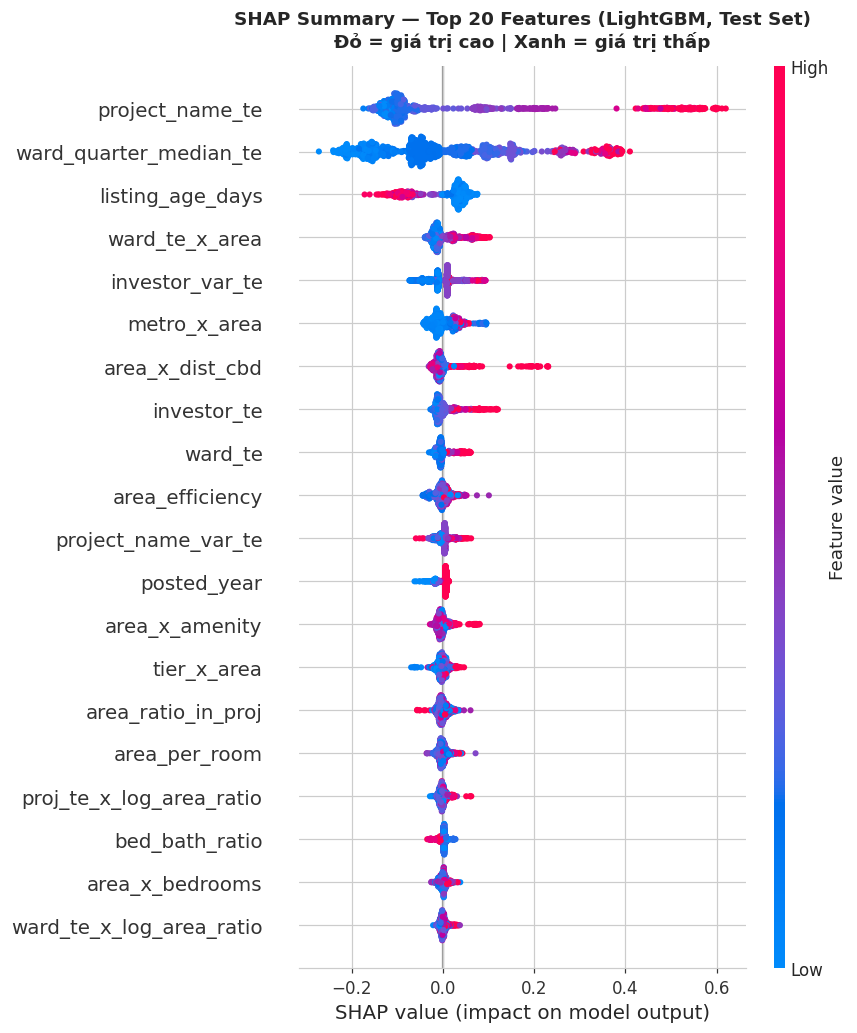

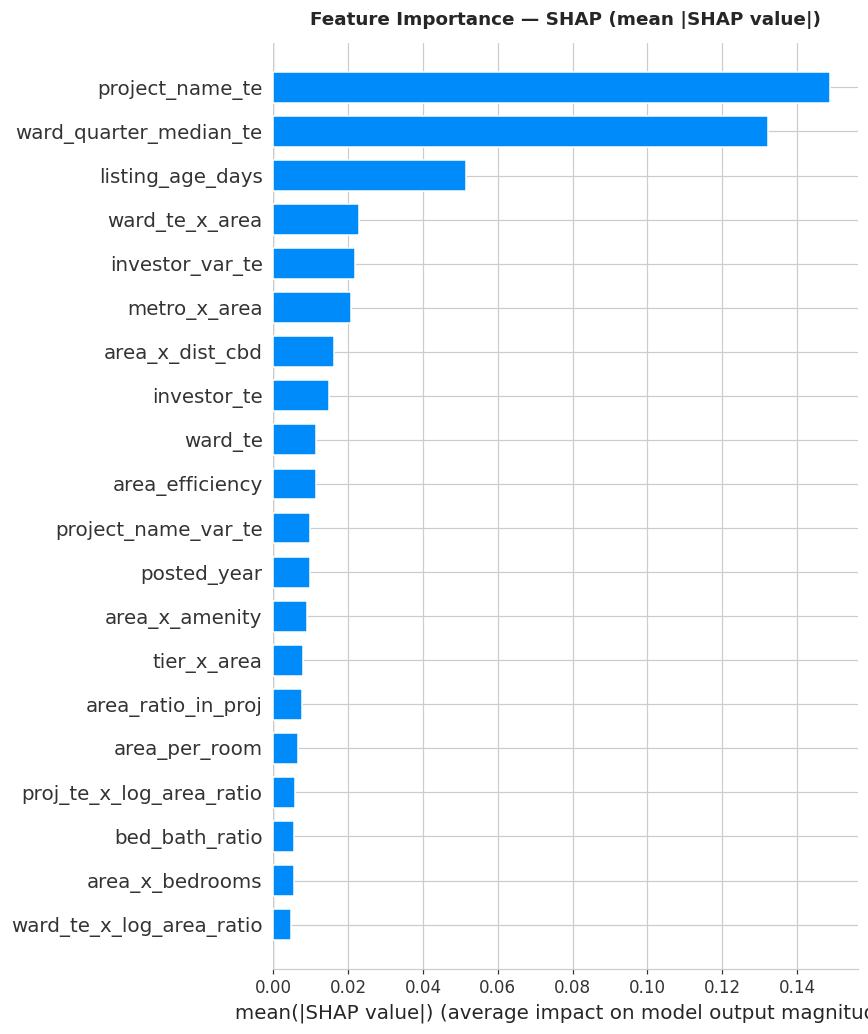


── Top 25 Features theo SHAP ──
project_name_te                  0.1489
ward_quarter_median_te           0.1323
listing_age_days                 0.0516
ward_te_x_area                   0.0228
investor_var_te                  0.0219
metro_x_area                     0.0208
area_x_dist_cbd                  0.0163
investor_te                      0.0149
ward_te                          0.0115
area_efficiency                  0.0113
project_name_var_te              0.0098
posted_year                      0.0097
area_x_amenity                   0.0090
tier_x_area                      0.0080
area_ratio_in_proj               0.0077
area_per_room                    0.0067
proj_te_x_log_area_ratio         0.0059
bed_bath_ratio                   0.0055
area_x_bedrooms                  0.0055
ward_te_x_log_area_ratio         0.0046
posted_month                     0.0041
years_to_handover                0.0041
ward_te_x_dist_cbd               0.0038
legal_status__Hợp đồng mua bán   0.0037
log_are

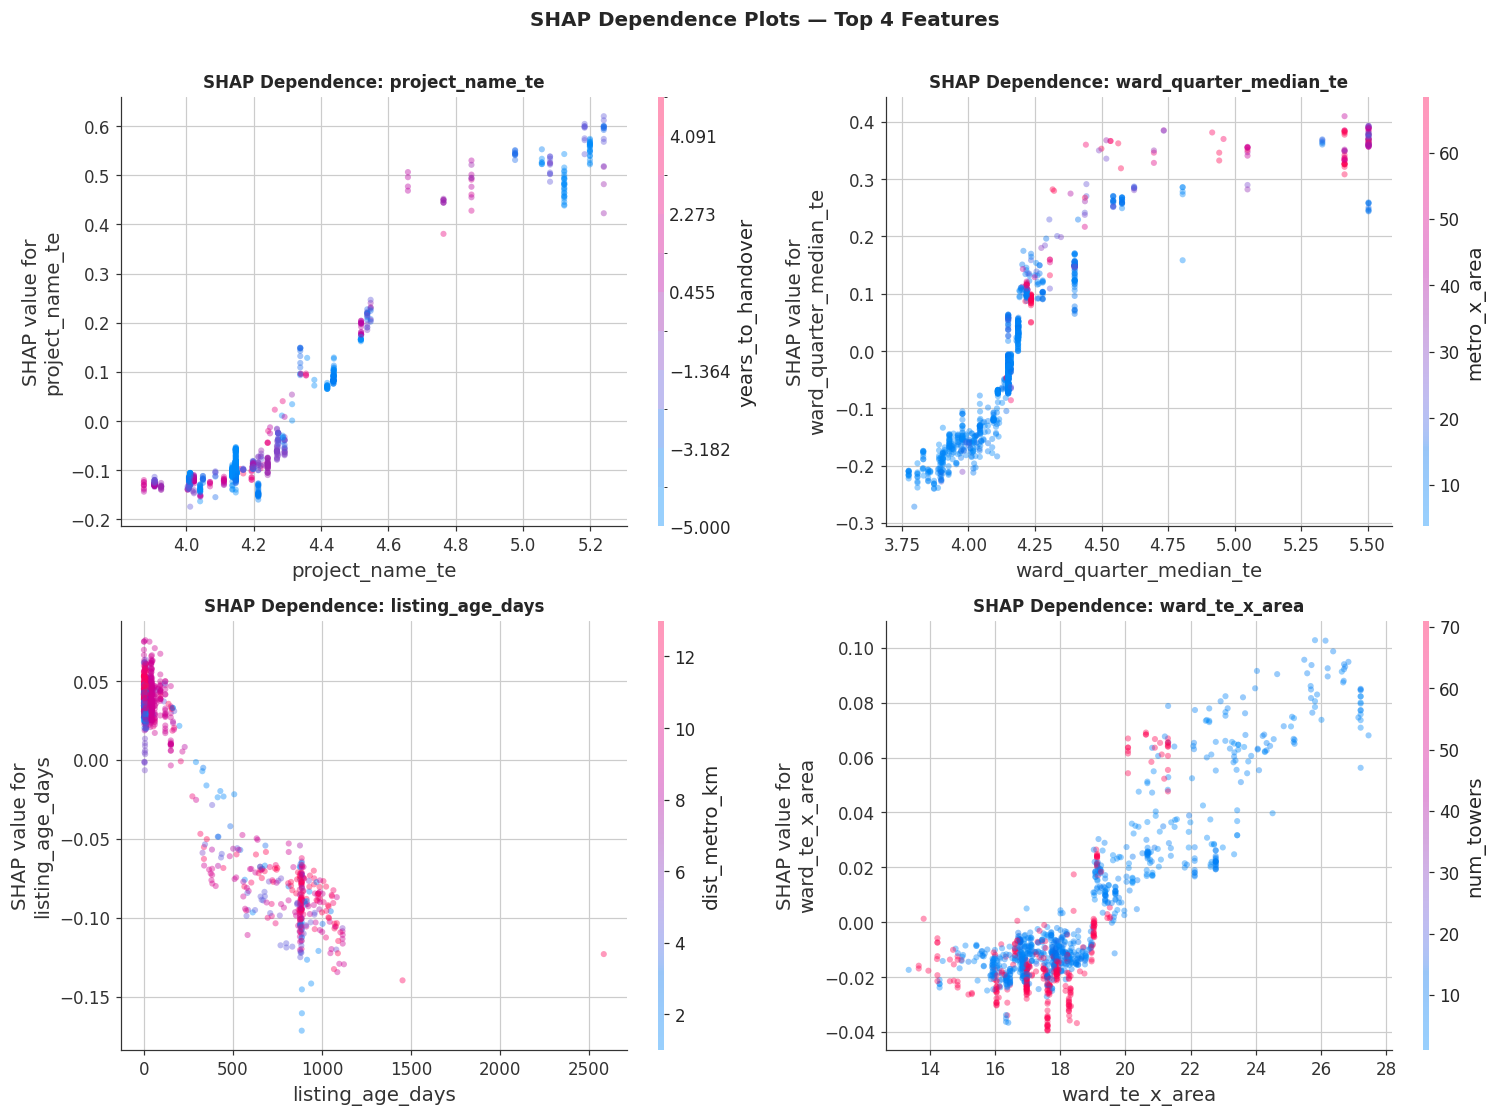

  ✅ shap_waterfall_211.png
  ✅ shap_waterfall_308.png
  ✅ shap_waterfall_822.png


In [ ]:
print("Computing SHAP values (30-90s)...")
explainer = shap.TreeExplainer(lgb_model)

# BUG FIX: dùng X_test để SHAP summary nhất quán với evaluation + waterfall
shap_values   = explainer.shap_values(X_test)
shap_X        = X_test
feature_names = X_test.columns.tolist()
mean_abs_shap = np.abs(shap_values).mean(axis=0)
print(f"✅ SHAP values shape: {shap_values.shape}")

# Summary Beeswarm
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, shap_X, max_display=20, show=False, plot_type="dot")
plt.title("SHAP Summary — Top 20 Features (LightGBM, Test Set)\nĐỏ = giá trị cao | Xanh = giá trị thấp",
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout(); plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150); plt.show()

# Bar (mean |SHAP|)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_X, max_display=20, show=False, plot_type="bar")
plt.title("Feature Importance — SHAP (mean |SHAP value|)", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout(); plt.savefig('shap_bar.png', bbox_inches='tight', dpi=150); plt.show()

shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)
print("\n── Top 25 Features theo SHAP ──")
print(shap_importance.head(25).round(4).to_string())

# Dependence: top 4
top4_features = shap_importance.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feat in enumerate(top4_features):
    shap.dependence_plot(feat, shap_values, shap_X, ax=axes.flatten()[i], show=False, alpha=0.4)
    axes.flatten()[i].set_title(f"SHAP Dependence: {feat}", fontsize=11, fontweight='bold')
plt.suptitle("SHAP Dependence Plots — Top 4 Features", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=150); plt.show()

# Waterfall: best / worst / median
y_true_real = np.expm1(y_test.values)
y_pred_real = np.expm1(lgb_pred_test)
abs_errors  = np.abs(y_true_real - y_pred_real)
expected_value = explainer.expected_value

cases = {
    f"Tốt nhất (err={abs_errors.min():.1f}tr)":   abs_errors.argmin(),
    f"Tệ nhất (err={abs_errors.max():.1f}tr)":    abs_errors.argmax(),
    f"Trung bình (err={np.median(abs_errors):.1f}tr)": np.argsort(abs_errors)[len(abs_errors)//2],
}
for title, idx in cases.items():
    plt.figure()
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[idx], base_values=expected_value,
                         data=X_test.iloc[idx], feature_names=feature_names),
        max_display=12, show=False
    )
    plt.title(title, fontsize=10, fontweight='bold')
    fname = f"shap_waterfall_{idx}.png"
    plt.savefig(fname, bbox_inches='tight', dpi=130); plt.close()
    print(f"  ✅ {fname}")


## Cell 19 — Model Comparison Dashboard

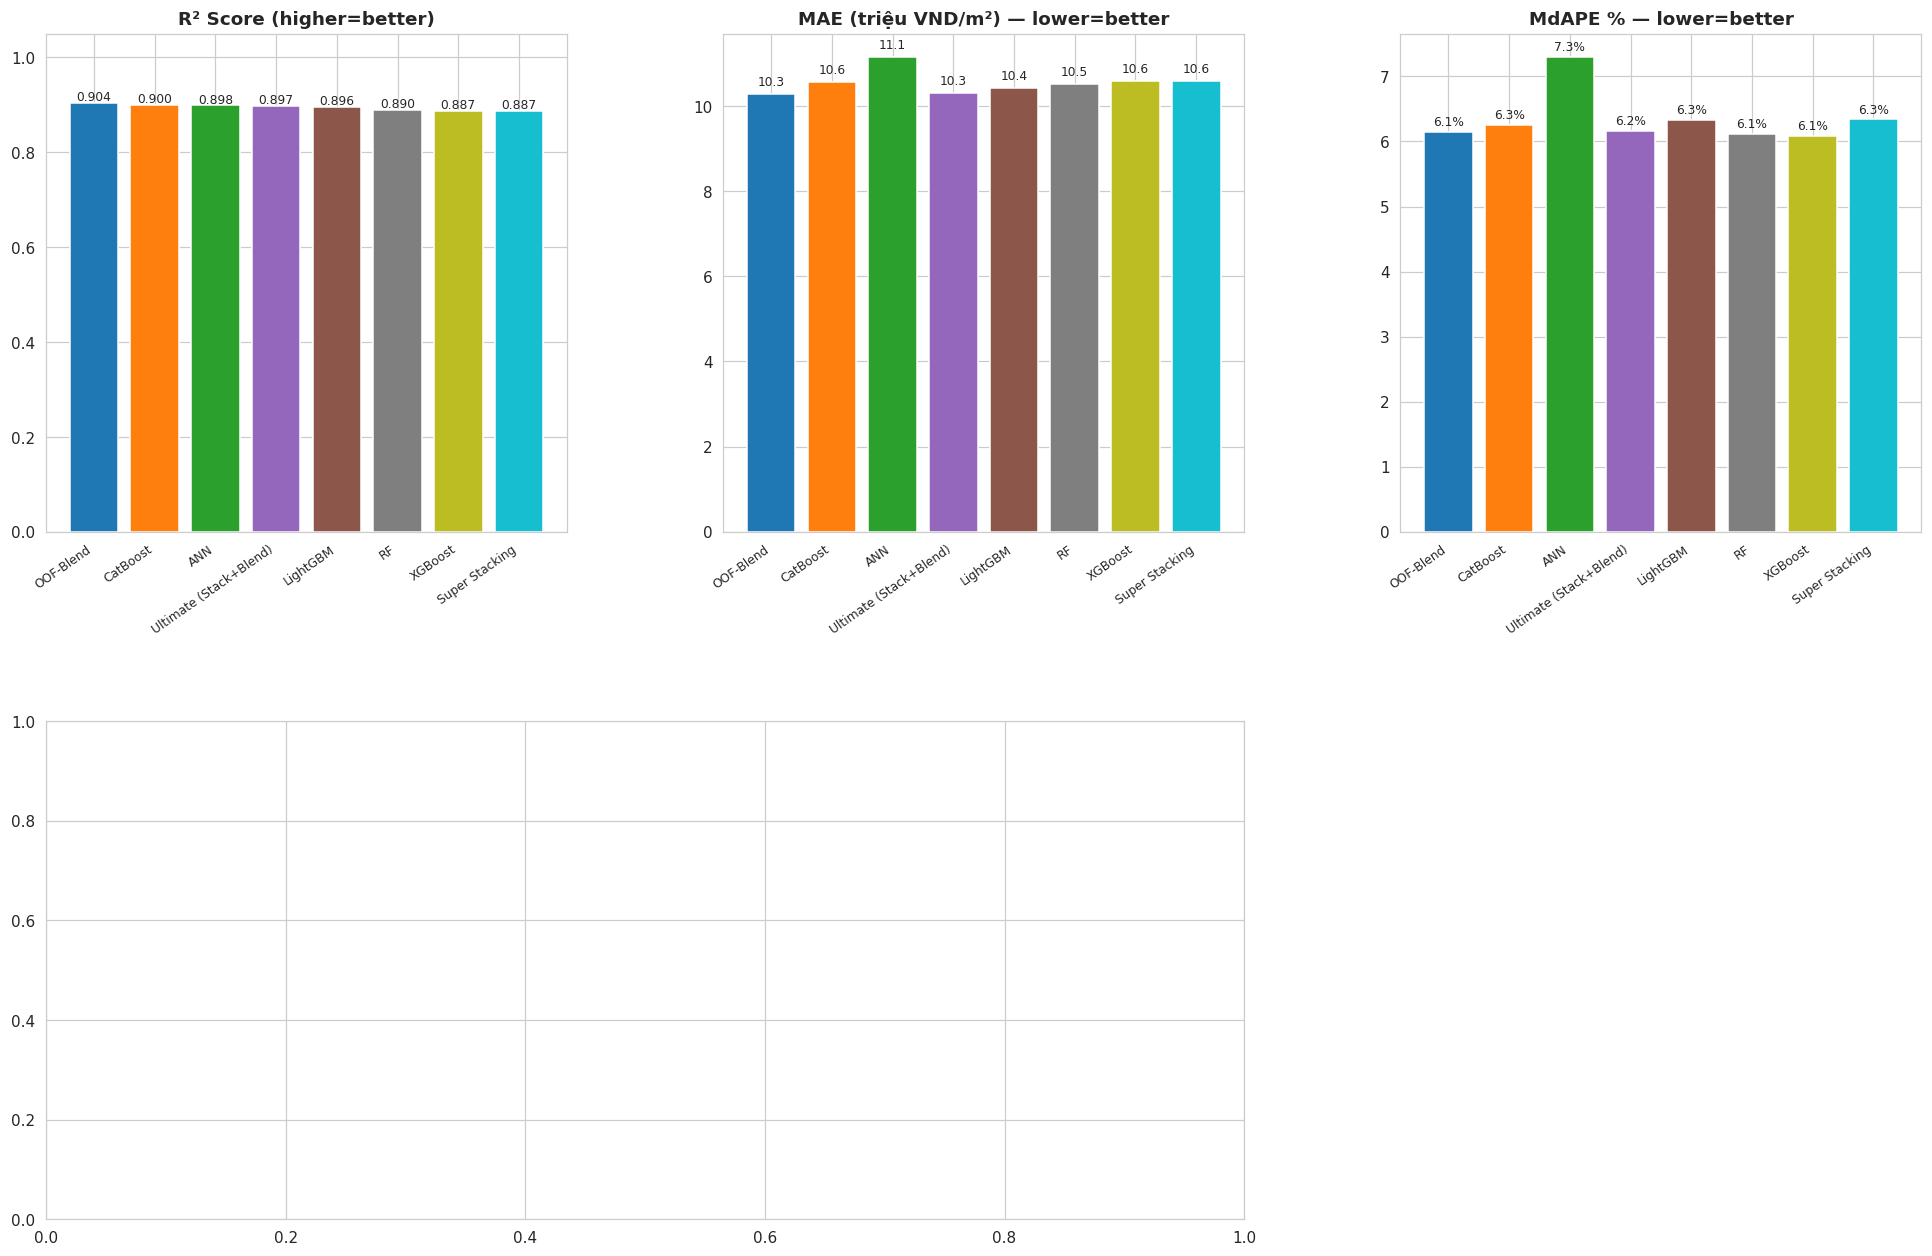

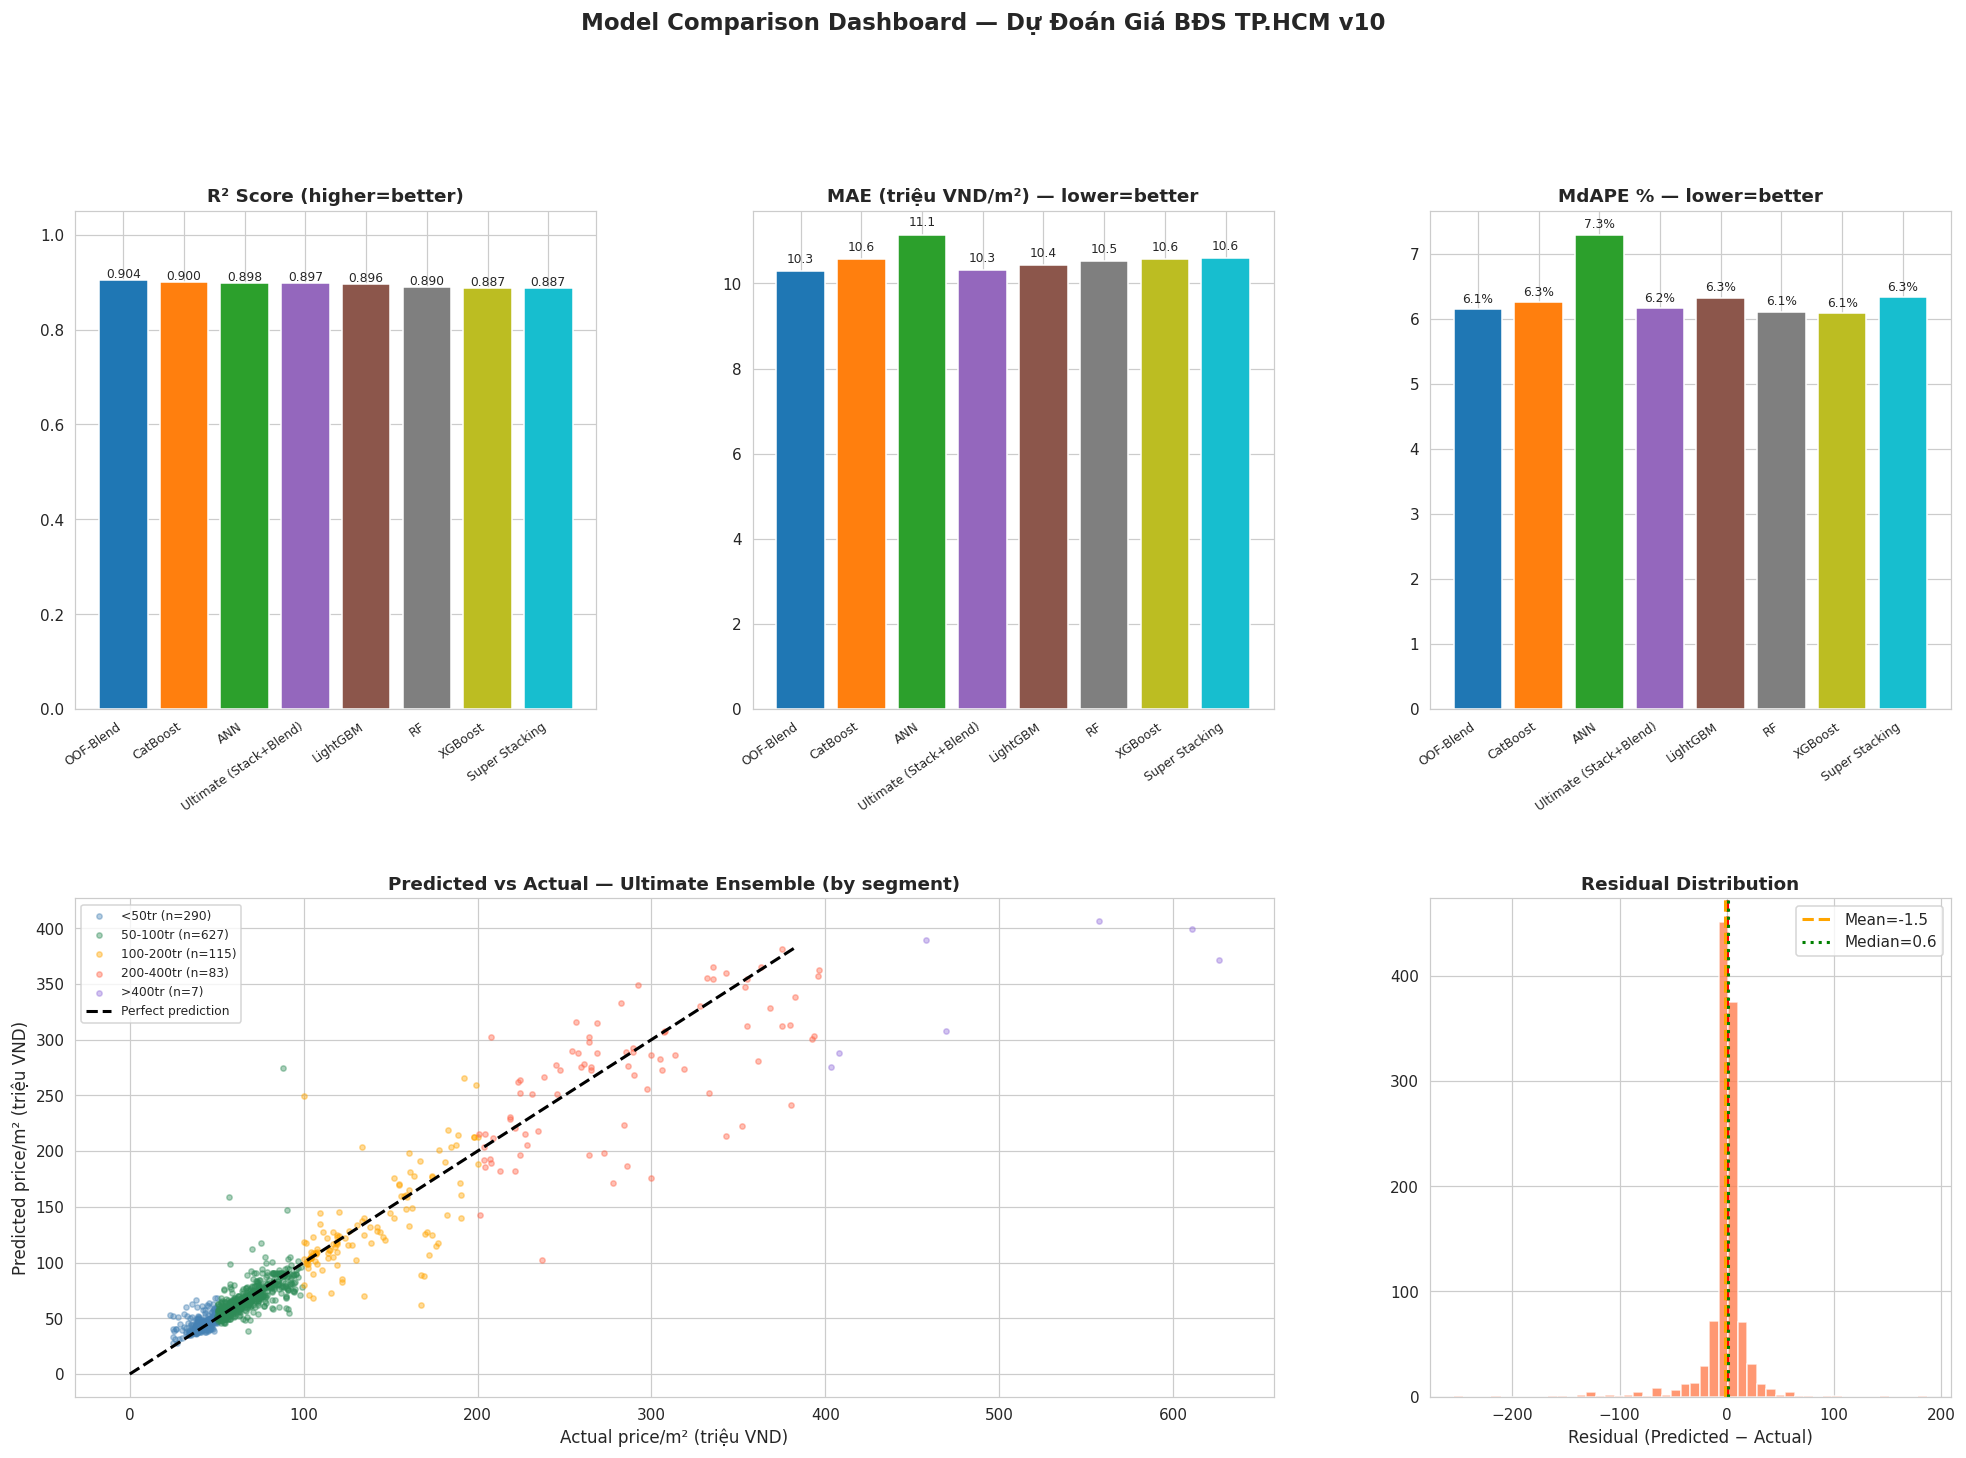


🏆 BEST: OOF-Blend  R²=0.9039  MAE=10.28  MdAPE=6.15%


In [ ]:
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.3)
models  = results_df['model'].tolist()
colors  = plt.cm.tab10(np.linspace(0, 1, len(models)))
x_pos   = np.arange(len(models))

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(x_pos, results_df['R2'], color=colors)
ax1.set_xticks(x_pos); ax1.set_xticklabels(models, rotation=35, ha='right', fontsize=8)
ax1.set_title('R² Score (higher=better)', fontweight='bold'); ax1.set_ylim(0, 1.05)
for bar, val in zip(bars, results_df['R2']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(x_pos, results_df['MAE'], color=colors)
ax2.set_xticks(x_pos); ax2.set_xticklabels(models, rotation=35, ha='right', fontsize=8)
ax2.set_title('MAE (triệu VND/m²) — lower=better', fontweight='bold')
for bar, val in zip(bars, results_df['MAE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}', ha='center', fontsize=8)

ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(x_pos, results_df['MdAPE_pct'], color=colors)
ax3.set_xticks(x_pos); ax3.set_xticklabels(models, rotation=35, ha='right', fontsize=8)
ax3.set_title('MdAPE % — lower=better', fontweight='bold')
for bar, val in zip(bars, results_df['MdAPE_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1, f'{val:.1f}%', ha='center', fontsize=8)

# Predicted vs Actual (Ultimate, color by segment)
ax4 = fig.add_subplot(gs[1, :2])
y_true_plot = np.expm1(y_test.values)
y_pred_plot = np.expm1(ultimate_pred)
segments = pd.cut(y_true_plot, bins=[0,50,100,200,400,np.inf],
                  labels=['<50tr','50-100tr','100-200tr','200-400tr','>400tr'])
seg_colors = {'<50tr':'steelblue','50-100tr':'seagreen','100-200tr':'orange','200-400tr':'tomato','>400tr':'mediumpurple'}
for seg, c in seg_colors.items():
    mask = (segments == seg)
    if mask.sum() < 3: continue
    ax4.scatter(y_true_plot[mask], y_pred_plot[mask], alpha=0.4, s=12, color=c, label=f'{seg} (n={mask.sum()})')
lim = np.percentile(y_true_plot, 99)
ax4.plot([0,lim],[0,lim],'k--',lw=2,label='Perfect prediction')
ax4.set_xlabel('Actual price/m² (triệu VND)', fontsize=11)
ax4.set_ylabel('Predicted price/m² (triệu VND)', fontsize=11)
ax4.set_title('Predicted vs Actual — Ultimate Ensemble (by segment)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 2])
residuals = y_pred_plot - y_true_plot
ax5.hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.8)
ax5.axvline(0, color='red', lw=2, ls='--')
ax5.axvline(residuals.mean(), color='orange', lw=2, ls='--', label=f'Mean={residuals.mean():.1f}')
ax5.axvline(np.median(residuals), color='green', lw=2, ls=':', label=f'Median={np.median(residuals):.1f}')
ax5.set_xlabel('Residual (Predicted − Actual)', fontsize=11)
ax5.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax5.legend()

plt.suptitle('Model Comparison Dashboard — Dự Đoán Giá BĐS TP.HCM v10', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('model_comparison_v10.png', dpi=120, bbox_inches='tight')
plt.show()
best_row = results_df.iloc[0]
print(f"\n🏆 BEST: {best_row['model']}  R²={best_row['R2']:.4f}  MAE={best_row['MAE']:.2f}  MdAPE={best_row['MdAPE_pct']:.2f}%")


## Cell 20 — Save Results

In [ ]:
results_df.to_csv('model_comparison_v10.csv', index=False)
print("✅ model_comparison_v10.csv")

# BUG FIX: to_frame() đặt tên cột đúng thay vì dùng rename trick bị lỗi
shap_importance.to_frame('shap_mean').reset_index().rename(
    columns={'index': 'feature'}
).to_csv('feature_importance_shap_v10.csv', index=False)
print("✅ feature_importance_shap_v10.csv")

pred_df = pd.DataFrame({
    'y_true_log':  y_test.values,
    'y_true_tr':   np.expm1(y_test.values),
    'lgb_tr':      np.expm1(lgb_pred_test),
    'xgb_tr':      np.expm1(xgb_pred_test),
    'rf_tr':       np.expm1(rf_pred_test),
    'blend_tr':    np.expm1(blend_preds),
    'stacking_tr': np.expm1(stacking_pred),
    'ultimate_tr': np.expm1(ultimate_pred),
})
if USE_CATBOOST and cat_oof_r2 > 0:
    pred_df['cat_tr'] = np.expm1(cat_pred_test)
if USE_ANN and ann_oof_r2 > 0:
    pred_df['ann_tr'] = np.expm1(ann_pred_test)
pred_df.to_csv('test_predictions_v10.csv', index=False)
print("✅ test_predictions_v10.csv")

print(f"\n{'='*65}\nFINAL SUMMARY — v10\n{'='*65}")
print(results_df[['model','R2','MAE','MdAPE_pct']].round(3).to_string(index=False))
print(f"\nTop 15 Features (SHAP):")
print(shap_importance.head(15).round(4).to_string())
